## Seguimos intentanto generar gaps, que ya logramos algunos pero solo con la definicon de "Zonas muertas" o "Dead Zones".

Voy a usar la libreria de dustpylib que es util para generar substrucutras que son fisicamnete correctas.

In [4]:
from dustpy import constants as c
from dustpylib.substructures.gaps import kanagawa2017
from tripodpy import Simulation

fortran mie routines unavailable


C:\astro\tripodpy\env_tripod\Lib\site-packages\dsharp_opac\dsharp_opac.py:47: UserWarning: could not import compiled mie code - mie calculation will be slow
  warnings.warn(
C:\astro\tripodpy\env_tripod\Lib\site-packages\dsharp_opac\dsharp_opac.py:57: UserWarning: numba not available, opacity calculation will be very slow
  warnings.warn(


In [ ]:
sim = Simulation()
sim.initialize()


In [5]:
sim.writer.datadir = "bumps/bp_2_v1"

In [6]:
sim.gas.alpha

[0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001
 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001
 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001
 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001
 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001
 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001
 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001
 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001
 0.001 0.001 0.001 0.001]

In [ ]:
def gap_updater(sim):
    alpha0 = 1e-3
    a_planet = 50 * c.au   # Ubicamos un planeta masivo en 50 AU
    q_planet = 1e-3        # Para forzar un hundimiento profundo
    h = sim.gas.Hp / sim.grid.r  
    perfil = kanagawa2017(sim.grid.r, a_planet, q_planet, h, alpha0)
    return alpha0 / perfil # Alteramos la viscosidad subyacente para construir el gap

sim.gas.alpha.updater.updater = gap_updater

# Al correr tu simulacion con sim.run() el surco de formará automáticamente!

In [7]:
sim.run()


tripodpy v1.0.0

Creating data directory bumps\bp_2_v1.
Writing file bumps\bp_2_v1\data0000.hdf5
Writing dump file bumps\bp_2_v1\frame.dmp
Writing file bumps\bp_2_v1\data0001.hdf5
Writing dump file bumps\bp_2_v1\frame.dmp
Writing file bumps\bp_2_v1\data0002.hdf5
Writing dump file bumps\bp_2_v1\frame.dmp
Writing file bumps\bp_2_v1\data0003.hdf5
Writing dump file bumps\bp_2_v1\frame.dmp
Writing file bumps\bp_2_v1\data0004.hdf5
Writing dump file bumps\bp_2_v1\frame.dmp
Writing file bumps\bp_2_v1\data0005.hdf5
Writing dump file bumps\bp_2_v1\frame.dmp
Writing file bumps\bp_2_v1\data0006.hdf5
Writing dump file bumps\bp_2_v1\frame.dmp
Writing file bumps\bp_2_v1\data0007.hdf5
Writing dump file bumps\bp_2_v1\frame.dmp
Writing file bumps\bp_2_v1\data0008.hdf5
Writing dump file bumps\bp_2_v1\frame.dmp
Writing file bumps\bp_2_v1\data0009.hdf5
Writing dump file bumps\bp_2_v1\frame.dmp
Writing file bumps\bp_2_v1\data0010.hdf5
Writing dump file bumps\bp_2_v1\frame.dmp
Writing file bumps\bp_2_v1\dat

c:\astro\Codigos practica + docs + papers\codigos\grid_extension.py:196: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  axs[1, 1].axhline(1.0, color='white', linestyle=':', label='Límite $\epsilon = 1$', alpha=0.5)


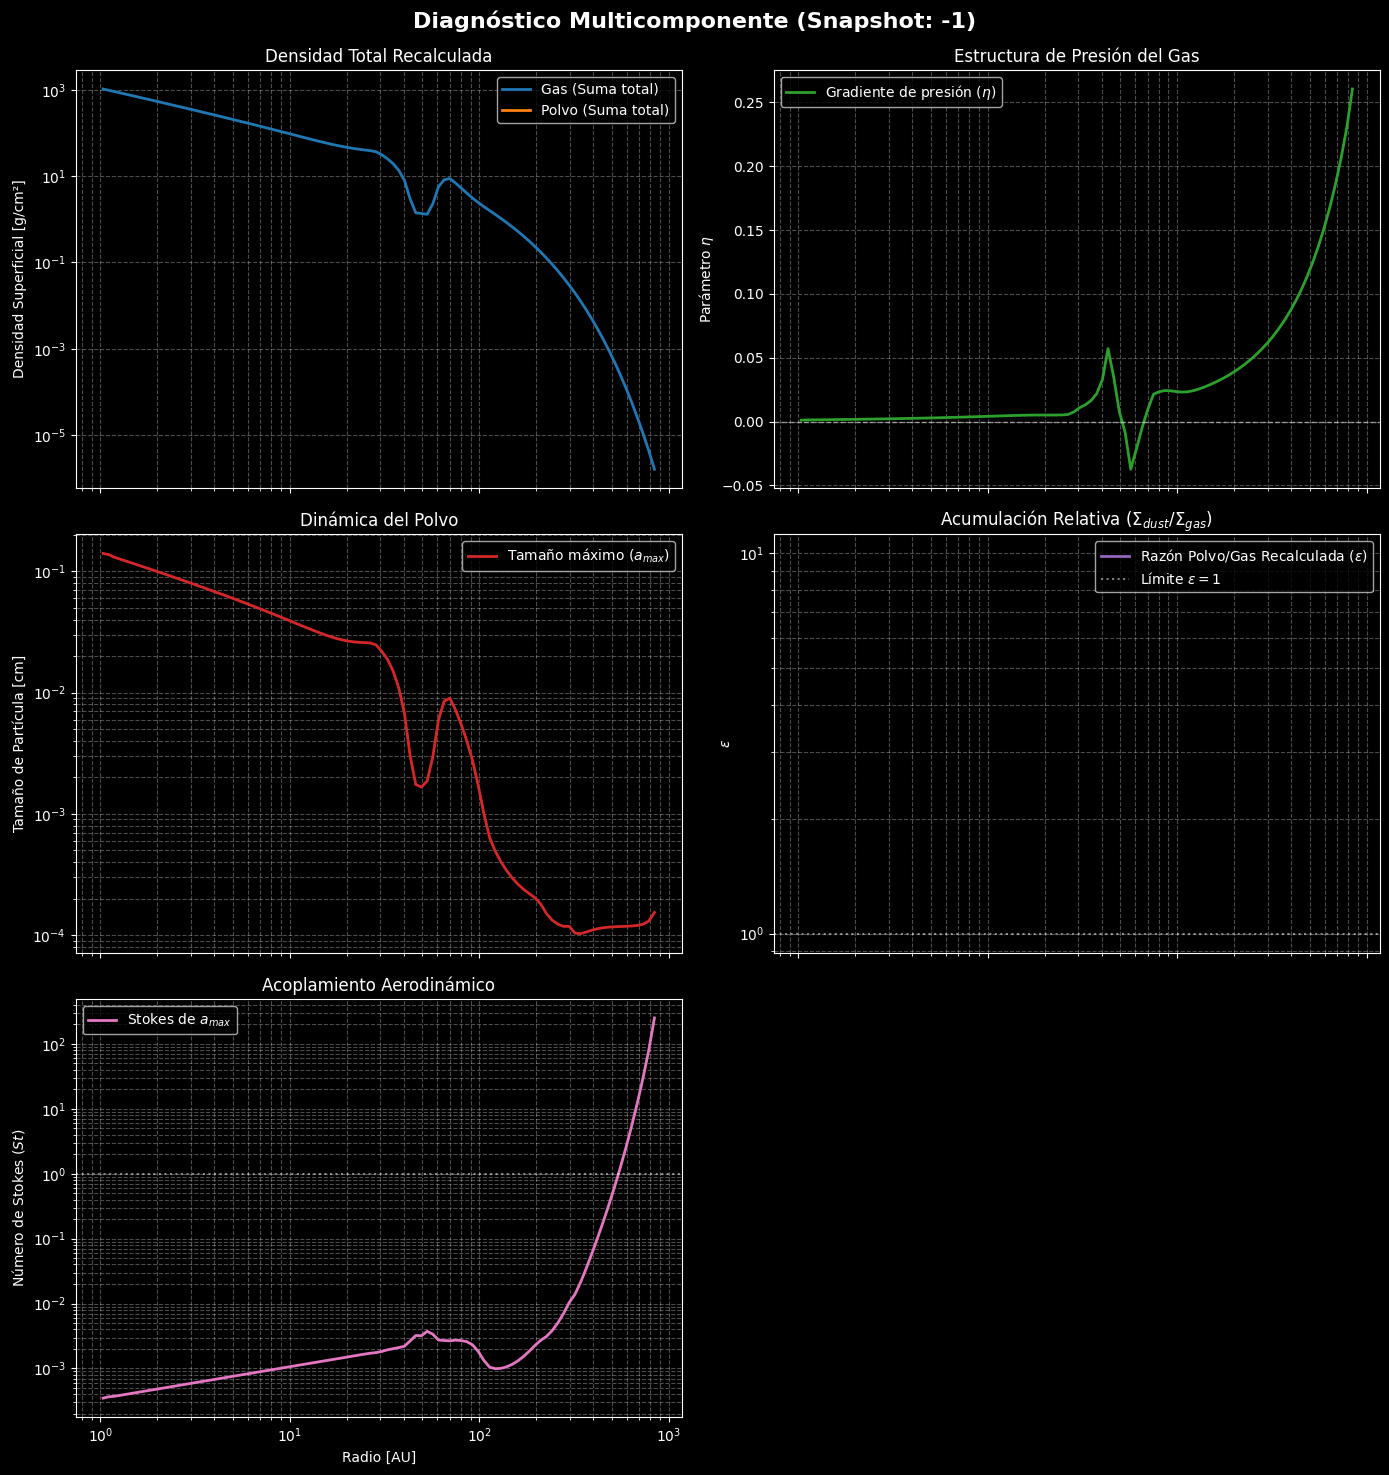

In [8]:
from grid_extension import plot_disk_diagnostics_multicomp

plot_disk_diagnostics_multicomp(sim)

In [32]:
# 1. MÉTODO: Drążkowska et al. 2016 (Sinks / Planetesimales)
from tripodpy import Simulation
from dustpy import constants as c
from dustpylib.planetesimals.formation import drazkowska2016

import numpy as np

def draz_updater(sim):
    St_adapted = sim.dust.St[:, [0, 4]] 
    return drazkowska2016(sim.grid.OmegaK, 
                        sim.dust.rho, 
                        sim.gas.rho,
                        sim.dust.Sigma, 
                        St_adapted, 
                        p2g_crit=0.01,
                        St_crit=0.01, 
                        zeta=0.01)


sim_draz = Simulation()
sim_draz.ini.grid.Nr = 150
sim_draz.makegrids()
sim_draz.initialize()

# Inyectando el sumidero que desaparece el polvo (Source term negativo)
sim_draz.dust.S.ext.updater.updater = draz_updater

sim_draz.writer.datadir = "bumps/gap_drazkowska_v2"
sim_draz.run()



tripodpy v1.0.0



ValueError: operands could not be broadcast together with shapes (150,2) (150,5) () 

In [33]:
# 2. MÉTODO: Miller et al. 2021 (Sinks / Planetesimales Suavizado)
from tripodpy import Simulation
from dustpy import constants as c
from dustpylib.planetesimals.formation import miller2021

import numpy as np

def miller_updater(sim):
    St_adapted = sim.dust.St[:, [0, 4]] 
    return miller2021(sim.grid.OmegaK,
                    sim.dust.rho, 
                    sim.gas.rho, 
                    sim.dust.Sigma, 
                    St_adapted, 
                    d2g_crit=0.01, 
                    n=0.03, 
                    zeta=0.1)



sim_miller = Simulation()
sim_miller.ini.grid.Nr = 150
sim_miller.makegrids()
sim_miller.initialize()

sim_miller.dust.S.ext.updater.updater = miller_updater

sim_miller.writer.datadir = "bumps/gap_miller_v2"
sim_miller.run()



tripodpy v1.0.0

Creating data directory bumps\gap_miller_v2.
Writing file bumps\gap_miller_v2\data0000.hdf5
Writing dump file bumps\gap_miller_v2\frame.dmp
Writing file bumps\gap_miller_v2\data0001.hdf5
Writing dump file bumps\gap_miller_v2\frame.dmp
Writing file bumps\gap_miller_v2\data0002.hdf5
Writing dump file bumps\gap_miller_v2\frame.dmp
Writing file bumps\gap_miller_v2\data0003.hdf5
Writing dump file bumps\gap_miller_v2\frame.dmp
Writing file bumps\gap_miller_v2\data0004.hdf5
Writing dump file bumps\gap_miller_v2\frame.dmp
Writing file bumps\gap_miller_v2\data0005.hdf5
Writing dump file bumps\gap_miller_v2\frame.dmp
Writing file bumps\gap_miller_v2\data0006.hdf5
Writing dump file bumps\gap_miller_v2\frame.dmp
Writing file bumps\gap_miller_v2\data0007.hdf5
Writing dump file bumps\gap_miller_v2\frame.dmp
Writing file bumps\gap_miller_v2\data0008.hdf5
Writing dump file bumps\gap_miller_v2\frame.dmp
Writing file bumps\gap_miller_v2\data0009.hdf5
Writing dump file bumps\gap_miller_

In [25]:
sim_miller.components

Group (components)
------------------
    Default      : Group (Default gas componentDefault (dust_tracer=False, gas_active=True, gas_tracer=False))
  -----

In [34]:
# 3. MÉTODO: Schoonenberg et al. 2018 (Sinks / Planetesimales Directo
from dustpylib.planetesimals.formation import schoonenberg2018

import numpy as np

import numpy as np

def schoo_updater(sim):
    St_adapted = sim.dust.St[:, [0, 4]] 
    
    return schoonenberg2018(
        sim.grid.OmegaK, 
        sim.dust.rho, 
        sim.gas.rho, 
        sim.dust.Sigma, 
        St_adapted, 
        d2g_crit=0.01,   # ¡AQUÍ ESTÁ LA MAGIA! Lo bajamos radicalmente
        zeta=0.1
    )


sim_schoo = Simulation()
sim_schoo.ini.grid.Nr = 150
sim_schoo.makegrids()
sim_schoo.initialize()

sim_schoo.dust.S.ext.updater.updater = schoo_updater

sim_schoo.writer.datadir = "bumps/gap_schoonenberg_v2"
sim_schoo.run()



tripodpy v1.0.0



RuntimeError: File bumps\gap_schoonenberg_v2\data0000.hdf5 already exists.

In [16]:
print("Forma de Sigma:", sim_schoo.dust.Sigma.shape)
print("Forma de St:", sim_schoo.dust.St.shape)


Forma de Sigma: (150, 2)
Forma de St: (150, 5)


In [20]:
print("Grupos dentro de Dust:", list(sim_schoo.dust.keys()))

# Veamos si existe una llave de componentes que nos acuse de dónde salen los 5
if hasattr(sim_schoo, 'components'):
    print("Componentes rastreados:", sim_schoo.components)

# Veamos el tamaño del grano de cada columna (¡esto nos dirá la verdad!)
print("Forma diametral (a):", sim_schoo.dust.a.shape)


AttributeError: 'Group' object has no attribute 'keys'

In [21]:
sim_schoo.dust

Group (Dust quantities)
-----------------------
    backreaction : Group (Backreaction coefficients)
    boundary     : Group (Boundary conditions)
    delta        : Group (Mixing parameters)
    f            : Group (Fudge factors)
    Fi           : Group (Fluxes)
    p            : Group (Probabilities)
    q            : Group (Distribution exponents)
    S            : Group (Sources)
    s            : Group (Characteristic particle sizes)
    v            : Group (Velocities)
  -----
    a            : Field (Particle sizes in cm: [a0, fudge * a1, a1, 0.5 * amax, amax])
    D            : Field (Diffusivity [cm²/s])
    eps          : Field (Dust-to-gas ratio)
    fill         : Field (Filling factor)
    H            : Field (Scale heights [cm])
    m            : Field (Particle mass [g])
    qrec         : Field (reconstructed distribution exponent)
    rho          : Field (Midplane mass density per mass bin [g/cm³])
    rhos         : Field (Solid state density [g/cm³])
  

In [12]:
# 4. MÉTODO: Duffell 2020 (Planetary Gap - Alterno a Kanagawa)
from tripodpy import Simulation
import numpy as np
from dustpy import constants as c
from dustpylib.substructures.gaps import duffell2020

def duffell_updater(sim):
    # Definimos alpha normal y el Júpiter en órbita
    alpha0 = 1e-3
    a_planet = 50 * c.au  
    q_planet = 1e-3       
    h = sim.gas.Hp / sim.grid.r  
    
    perfil = duffell2020(sim.grid.r, a_planet, q_planet, h, alpha0)
    return alpha0 / perfil

sim_duffell = Simulation()
sim_duffell.ini.grid.Nr = 150
sim_duffell.makegrids()
sim_duffell.initialize()

sim_duffell.gas.alpha.updater.updater = duffell_updater

# Al ser una modificación de gas.alpha, requerimos asentar valores primero
sim_duffell.gas.alpha.update()
sim_duffell.update()

sim_duffell.writer.datadir = "bumps/gap_duffell"
sim_duffell.run()



tripodpy v1.0.0

Creating data directory bumps\gap_duffell.
Writing file bumps\gap_duffell\data0000.hdf5
Writing dump file bumps\gap_duffell\frame.dmp
Writing file bumps\gap_duffell\data0001.hdf5
Writing dump file bumps\gap_duffell\frame.dmp
Writing file bumps\gap_duffell\data0002.hdf5
Writing dump file bumps\gap_duffell\frame.dmp
Writing file bumps\gap_duffell\data0003.hdf5
Writing dump file bumps\gap_duffell\frame.dmp
Writing file bumps\gap_duffell\data0004.hdf5
Writing dump file bumps\gap_duffell\frame.dmp
Writing file bumps\gap_duffell\data0005.hdf5
Writing dump file bumps\gap_duffell\frame.dmp
Writing file bumps\gap_duffell\data0006.hdf5
Writing dump file bumps\gap_duffell\frame.dmp
Writing file bumps\gap_duffell\data0007.hdf5
Writing dump file bumps\gap_duffell\frame.dmp
Writing file bumps\gap_duffell\data0008.hdf5
Writing dump file bumps\gap_duffell\frame.dmp
Writing file bumps\gap_duffell\data0009.hdf5
Writing dump file bumps\gap_duffell\frame.dmp
Writing file bumps\gap_duffel

In [3]:
from tripodpy import plot
plot("data_pre_pipeline/bumps/gap_duffell", it=-1)

TypeError: 'module' object is not callable

---
['delta',
 'rhos',
 'fill',
 'backreaction',
 'f',
 'qrec',
 'a',
 'm',
 'St',
 'H',
 'rho',
 'D',
 'eps',
 'v',
 'p',
 'q',
 'SigmaFloor',
 'S']

mira este es el update order del dust de cada simluacion

['star', 'grid', 'components', 'gas', 'dust']

luego este es el updadet de la siulacion en general

['Sigma',
 'mu',
 'T',
 'alpha',
 'cs',
 'Hp',
 'nu',
 'rho',
 'n',
 'mfp',
 'P',
 'eta',
 'torque',
 'S']

luego este es el update ordel del gas



## Agregamos la eficiencia mucho mejor para producir buenos gaps y agregar la componete para que se pueda guardar los datos que consume los planetesimales.

In [39]:
import numpy as np
from tripodpy import Simulation
from dustpy import constants as c
from dustpylib.planetesimals.formation import drazkowska2016
from simframe import Instruction, schemes

def draz_updater(sim):
    St_adapted = sim.dust.St[:, [0, 4]]
    # Activamos con límite 0.01 y devoramos con 50% de voracidad
    return drazkowska2016(
        sim.grid.OmegaK, sim.dust.rho, sim.gas.rho, sim.dust.Sigma, St_adapted,
        p2g_crit=0.01, St_crit=0.01, zeta=0.5
    )

sim_draz = Simulation()
sim_draz.ini.grid.Nr = 150
sim_draz.makegrids()
sim_draz.initialize()

sim_draz.dust.S.ext.updater.updater = draz_updater

# ----------------- RASTREADOR DE PLANETESIMALES -----------------
sim_draz.addgroup("planetesimals", description="Rocas formadas (Sinks)")
sim_draz.planetesimals.addfield("Sigma", np.zeros_like(sim_draz.gas.Sigma), description="Sigma Planetesimal [g/cm²]")

def dSigma_draz(s, t, Sigma_planetesimals): return -s.dust.S.ext.sum(-1)
sim_draz.planetesimals.Sigma.differentiator = dSigma_draz
sim_draz.integrator.instructions.append(Instruction(schemes.expl_1_euler, sim_draz.planetesimals.Sigma))
# ----------------------------------------------------------------

sim_draz.update()
sim_draz.writer.datadir = "bumps/gap_drazkowska_fast"
sim_draz.run()


ValueError: operands could not be broadcast together with shapes (150,2) (150,5) () 

In [42]:
import numpy as np
from tripodpy import Simulation
from dustpy import constants as c
from dustpylib.planetesimals.formation import miller2021
from simframe import Instruction, schemes

def miller_updater(sim):
    St_adapted = sim.dust.St[:, [0, 4]]
    # Transición suave desde 0.01 de densidad cruzada
    return miller2021(
        sim.grid.OmegaK, sim.dust.rho, sim.gas.rho, sim.dust.Sigma, St_adapted,
        d2g_crit=0.01, n=0.03, zeta=0.5
    )

sim_miller = Simulation()
sim_miller.ini.grid.Nr = 150
sim_miller.makegrids()
sim_miller.initialize()

tiempo = np.logspace(3, 6, num=30, base=10) * c.year
sim_miller.t.snapshots = tiempo

sim_miller.dust.S.ext.updater.updater = miller_updater

# ----------------- RASTREADOR DE PLANETESIMALES -----------------
sim_miller.addgroup("planetesimals", description="Rocas formadas (Sinks)")
sim_miller.planetesimals.addfield("Sigma", np.zeros_like(sim_miller.gas.Sigma), description="Sigma Planetesimal [g/cm²]")

def dSigma_miller(s, t, Sigma_planetesimals): return -s.dust.S.ext.sum(-1)
sim_miller.planetesimals.Sigma.differentiator = dSigma_miller
sim_miller.integrator.instructions.append(Instruction(schemes.expl_1_euler, sim_miller.planetesimals.Sigma))
# ----------------------------------------------------------------

sim_miller.update()
sim_miller.writer.datadir = "bumps/gap_miller_fast"
sim_miller.writer.overwrite = True
sim_miller.run()



tripodpy v1.0.0

Writing file bumps\gap_miller_fast\data0000.hdf5
Writing dump file bumps\gap_miller_fast\frame.dmp
Writing file bumps\gap_miller_fast\data0001.hdf5
Writing dump file bumps\gap_miller_fast\frame.dmp
Writing file bumps\gap_miller_fast\data0002.hdf5
Writing dump file bumps\gap_miller_fast\frame.dmp
Writing file bumps\gap_miller_fast\data0003.hdf5
Writing dump file bumps\gap_miller_fast\frame.dmp
Writing file bumps\gap_miller_fast\data0004.hdf5
Writing dump file bumps\gap_miller_fast\frame.dmp
Writing file bumps\gap_miller_fast\data0005.hdf5
Writing dump file bumps\gap_miller_fast\frame.dmp
Writing file bumps\gap_miller_fast\data0006.hdf5
Writing dump file bumps\gap_miller_fast\frame.dmp
Writing file bumps\gap_miller_fast\data0007.hdf5
Writing dump file bumps\gap_miller_fast\frame.dmp
Writing file bumps\gap_miller_fast\data0008.hdf5
Writing dump file bumps\gap_miller_fast\frame.dmp
Writing file bumps\gap_miller_fast\data0009.hdf5
Writing dump file bumps\gap_miller_fast\fr

c:\astro\Codigos practica + docs + papers\codigos\grid_extension.py:196: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  axs[1, 1].axhline(1.0, color='white', linestyle=':', label='Límite $\epsilon = 1$', alpha=0.5)


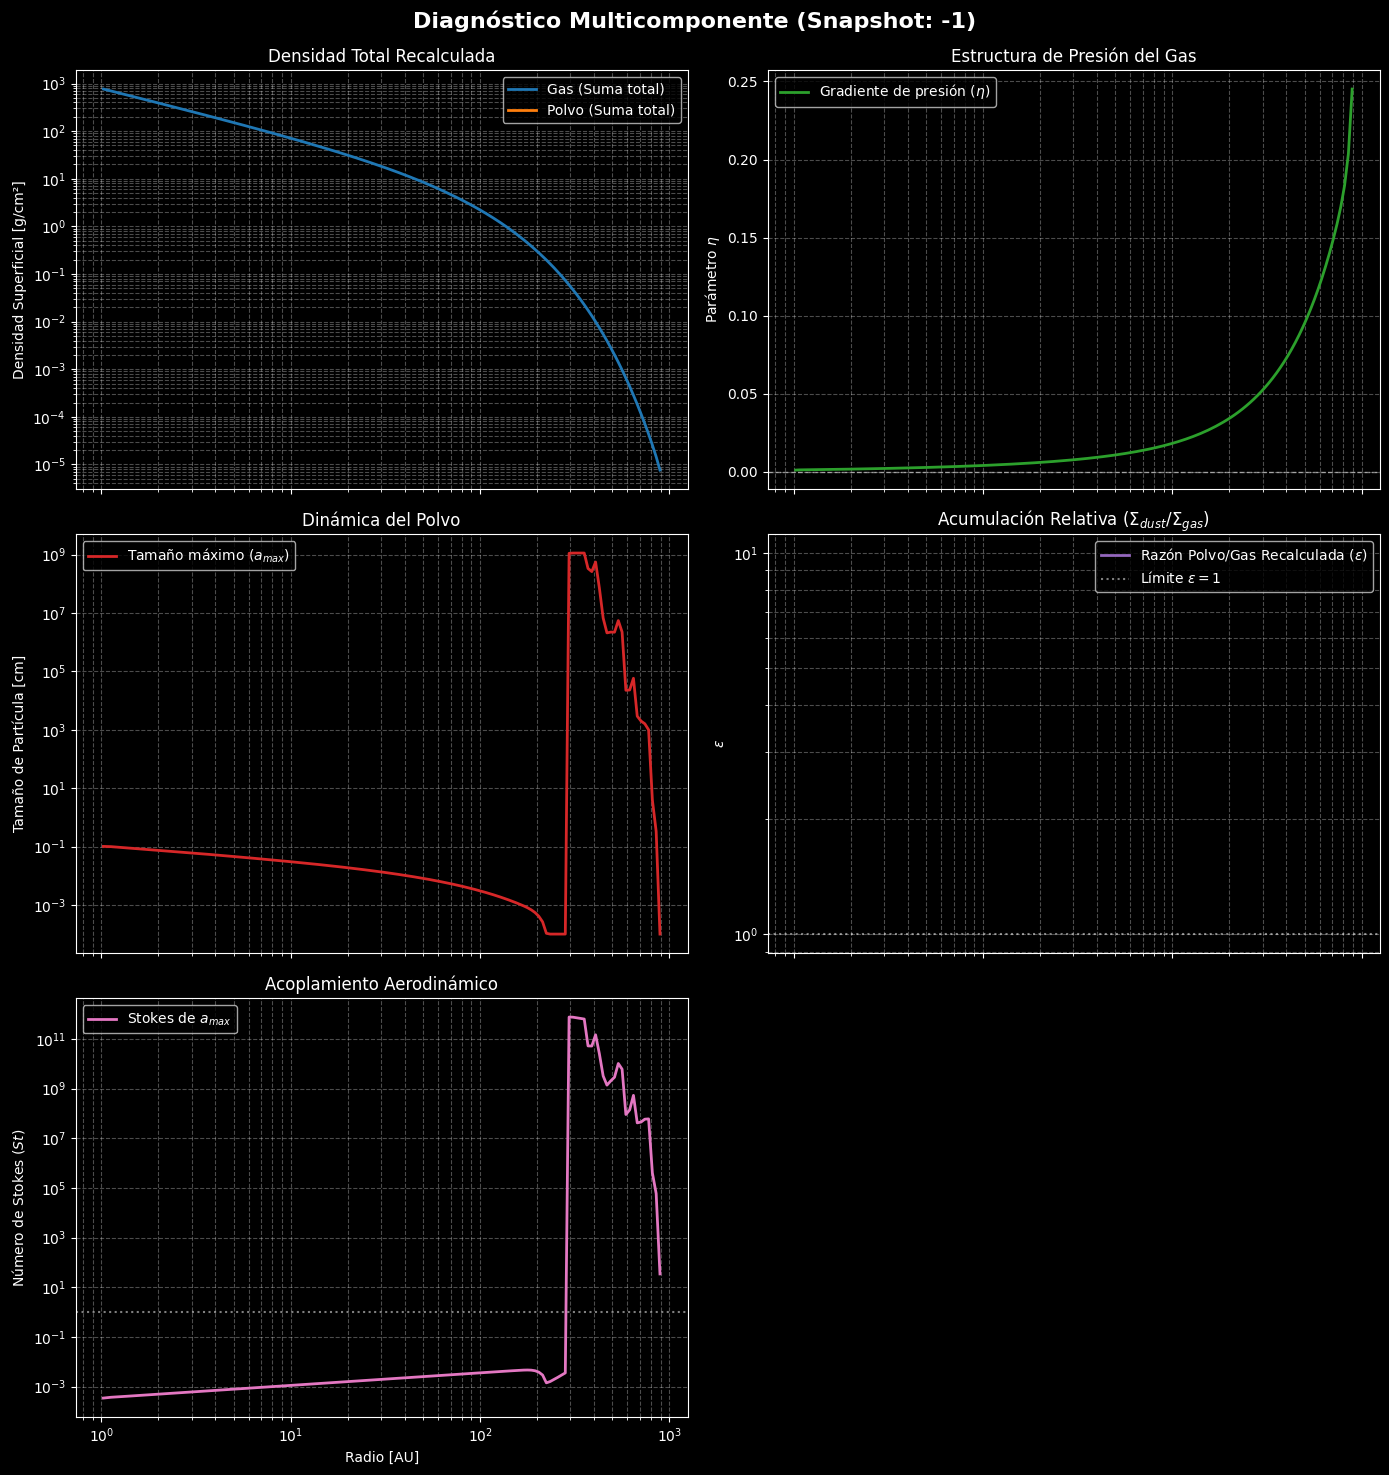

In [48]:
plot_disk_diagnostics_multicomp(sim_miller)

In [44]:
import numpy as np
from tripodpy import Simulation
from dustpy import constants as c
from dustpylib.planetesimals.formation import schoonenberg2018
from simframe import Instruction, schemes

def schoo_updater(sim):
    St_adapted = sim.dust.St[:, [0, 4]]
    # Relevo de masa universal, devorando todo si supera ratio de 0.01 (1% frente al gas)
    return schoonenberg2018(
        sim.grid.OmegaK, sim.dust.rho, sim.gas.rho, sim.dust.Sigma, St_adapted,
        d2g_crit=0.01, zeta=0.5
    )

sim_schoo = Simulation()
sim_schoo.ini.grid.Nr = 150
sim_schoo.makegrids()
sim_schoo.initialize()

sim_schoo.dust.S.ext.updater.updater = schoo_updater

# ----------------- RASTREADOR DE PLANETESIMALES -----------------
sim_schoo.addgroup("planetesimals", description="Rocas formadas (Sinks)")
sim_schoo.planetesimals.addfield("Sigma", np.zeros_like(sim_schoo.gas.Sigma), description="Sigma Planetesimal [g/cm²]")

def dSigma_schoo(s, t, Sigma_planetesimals): return -s.dust.S.ext.sum(-1)
sim_schoo.planetesimals.Sigma.differentiator = dSigma_schoo
sim_schoo.integrator.instructions.append(Instruction(schemes.expl_1_euler, sim_schoo.planetesimals.Sigma))
# ----------------------------------------------------------------

sim_schoo.update()
sim_schoo.t.snapshots = tiempo
sim_schoo.writer.datadir = "bumps/gap_schoo_fast"
sim_schoo.writer.overwrite = True
sim_schoo.run()



tripodpy v1.0.0

Creating data directory bumps\gap_schoo_fast.
Writing file bumps\gap_schoo_fast\data0000.hdf5
Writing dump file bumps\gap_schoo_fast\frame.dmp
Writing file bumps\gap_schoo_fast\data0001.hdf5
Writing dump file bumps\gap_schoo_fast\frame.dmp
Writing file bumps\gap_schoo_fast\data0002.hdf5
Writing dump file bumps\gap_schoo_fast\frame.dmp
Writing file bumps\gap_schoo_fast\data0003.hdf5
Writing dump file bumps\gap_schoo_fast\frame.dmp
Writing file bumps\gap_schoo_fast\data0004.hdf5
Writing dump file bumps\gap_schoo_fast\frame.dmp
Writing file bumps\gap_schoo_fast\data0005.hdf5
Writing dump file bumps\gap_schoo_fast\frame.dmp
Writing file bumps\gap_schoo_fast\data0006.hdf5
Writing dump file bumps\gap_schoo_fast\frame.dmp
Writing file bumps\gap_schoo_fast\data0007.hdf5
Writing dump file bumps\gap_schoo_fast\frame.dmp
Writing file bumps\gap_schoo_fast\data0008.hdf5
Writing dump file bumps\gap_schoo_fast\frame.dmp
Writing file bumps\gap_schoo_fast\data0009.hdf5
Writing dump fi

c:\astro\Codigos practica + docs + papers\codigos\grid_extension.py:196: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  axs[1, 1].axhline(1.0, color='white', linestyle=':', label='Límite $\epsilon = 1$', alpha=0.5)


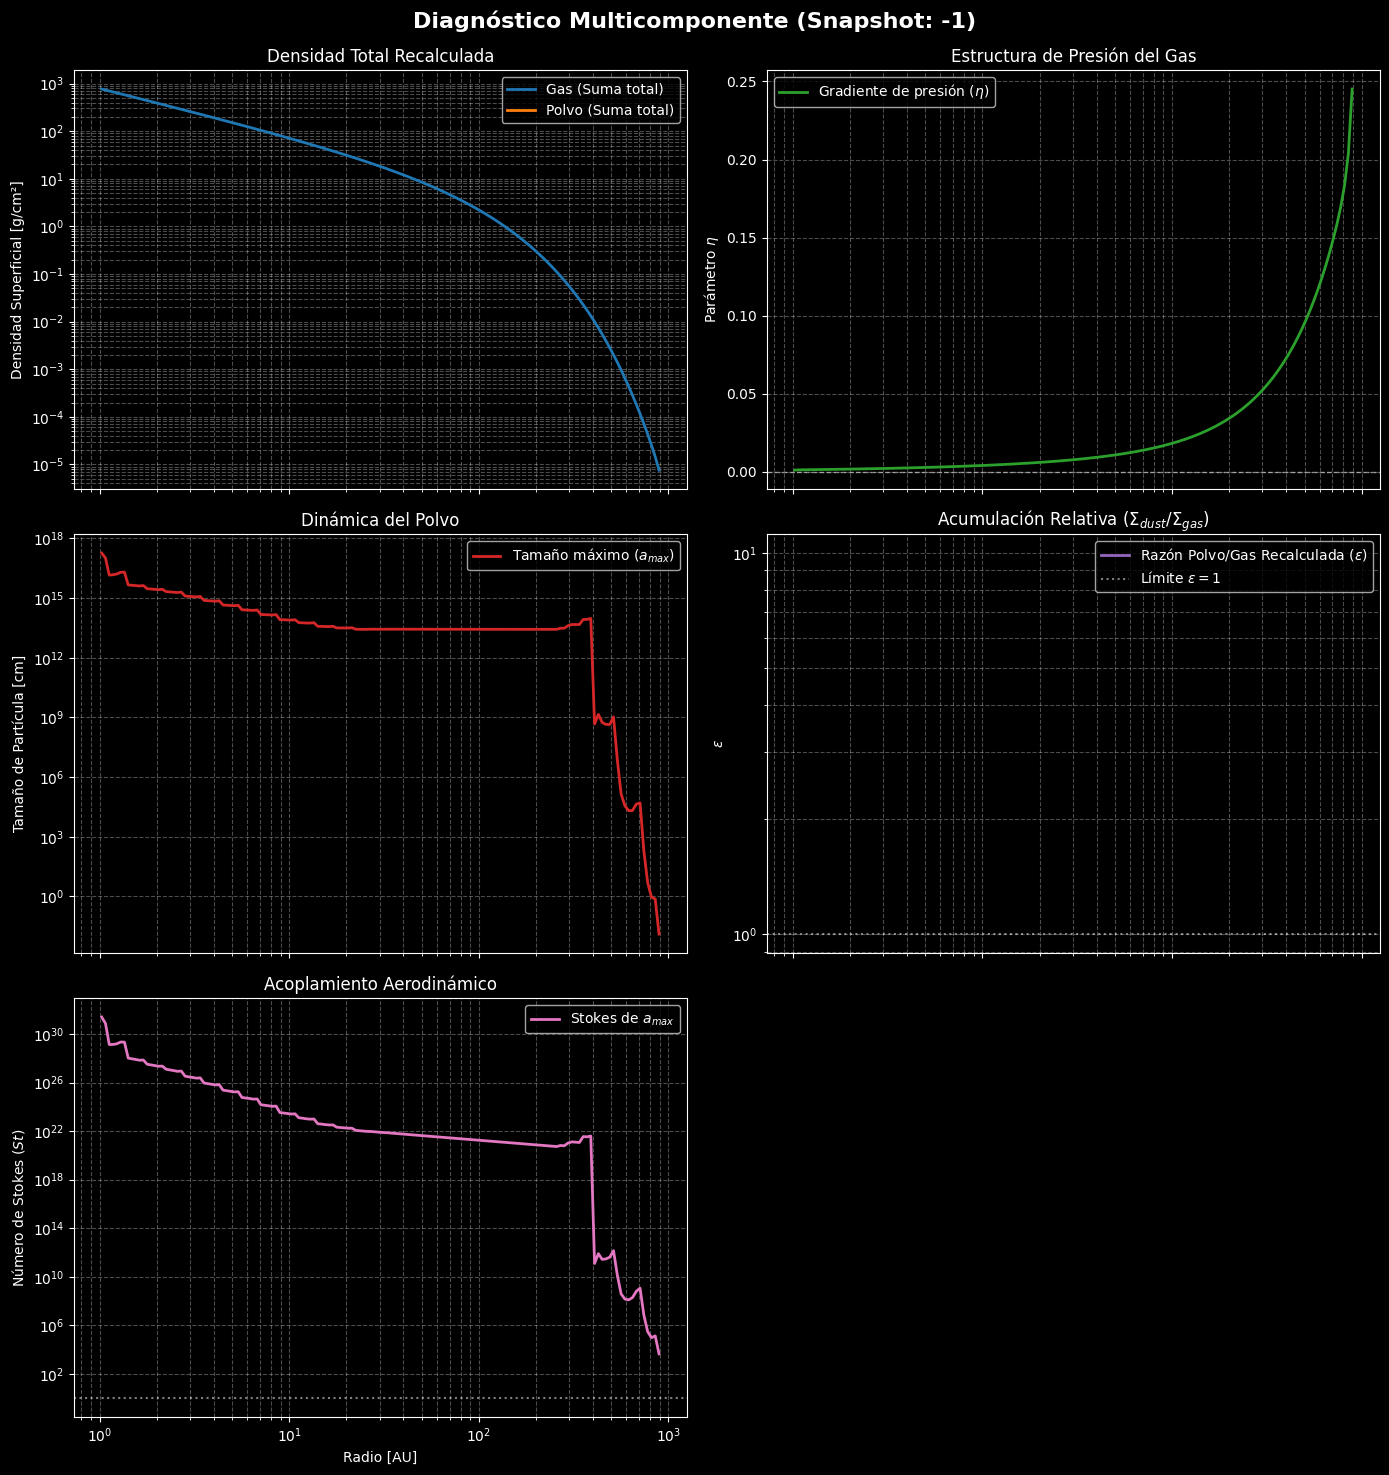

In [45]:
plot_disk_diagnostics_multicomp(sim_schoo)